# Phase kickback: a controlled gate that changes its *control* qubit

A controlled-$U$ gate is usually described as "apply $U$ to the target if the control is 1." But suppose the target is in an eigenstate of $U$:

$$U|\psi\rangle = e^{i\varphi}|\psi\rangle .$$

Applying $U$ then just multiplies the target by a phase and leaves it in the same state. By linearity, the controlled-$U$ gives

$$|0\rangle|\psi\rangle \to |0\rangle|\psi\rangle
\qquad
|1\rangle|\psi\rangle \to e^{i\varphi}\,|1\rangle|\psi\rangle .$$

The target is unchanged, but the phase $e^{i\varphi}$ now sits on the $|1\rangle$ part of the control. The phase has "kicked back" onto the control qubit.

This is the engine behind Deutsch-Jozsa, Bernstein-Vazirani, Simon, Grover, and phase estimation, so it is worth seeing on its own.

## How we measure it

A phase on $|1\rangle$ is invisible if we measure right away. So we start the control in $|+\rangle = (|0\rangle + |1\rangle)/\sqrt2$. After the kickback it is $(|0\rangle + e^{i\varphi}|1\rangle)/\sqrt2$, and a final Hadamard turns the phase into a probability:

$$P(\text{control measures } 1) = \sin^2(\varphi/2).$$

The circuit is

```
control : --H--*--H--measure
target  : ----[U]---      (target starts in an eigenstate of U)
```

## Cases we run

$U$ is the phase gate $P(\varphi)$, which multiplies $|1\rangle$ by $e^{i\varphi}$ and leaves $|0\rangle$ alone. So $|1\rangle$ is an eigenstate with eigenvalue $e^{i\varphi}$, and $|0\rangle$ is an eigenstate with eigenvalue 1.

| Case | Target | What happens | Expected $P(1)$ |
|---|---|---|---|
| `kick_phi=...` | $\lvert 1\rangle$ | the phase $\varphi$ kicks back | $\sin^2(\varphi/2)$ (0, 0.5, 1 for $\varphi = 0, \pi/2, \pi$) |
| `no_kick_phi=...` | $\lvert 0\rangle$ | eigenvalue is 1, nothing kicks back (control experiment) | 0 for every $\varphi$ |
| `cx_on_minus` | $\lvert -\rangle$ | $X\lvert -\rangle = -\lvert -\rangle$, so CX acts like a Z on the control | 1 |

The last case is the one used in Deutsch-Jozsa and Bernstein-Vazirani.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import math
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# _common.py (in the parent folder) holds the code that runs circuits on Aer and/or hardware.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)

# How far a measured P(1) may be from the ideal value and still be marked "ok".
# This leaves room for shot noise and hardware errors.
TOLERANCE = 0.1
PHASES = (0.0, 0.5, 1.0)  # phases phi to kick back, in units of pi

## Step 1: A circuit skeleton

Every circuit here has one control qubit, one target qubit, and one classical bit that records the control's measurement. This helper makes that empty circuit.

In [2]:
def skeleton(name):
    # Empty circuit: one control qubit, one target qubit, one classical bit.
    ctrl = QuantumRegister(1, name="ctrl")
    targ = QuantumRegister(1, name="targ")
    bits = ClassicalRegister(1, name="meas")
    return QuantumCircuit(ctrl, targ, bits, name=name), ctrl, targ

## Step 2: The kickback circuit

`build_kickback(phi, eigenstate)` builds a controlled-$P(\varphi)$ circuit that reads out the control's phase.

- If `eigenstate` is True, the target is $|1\rangle$ (eigenvalue $e^{i\varphi}$), so the phase kicks back.
- If False, the target is $|0\rangle$ (eigenvalue 1), so nothing does.

The sequence is: prepare the target, put the control in $|+\rangle$, apply the controlled phase gate, then a second Hadamard on the control turns the phase into a probability.

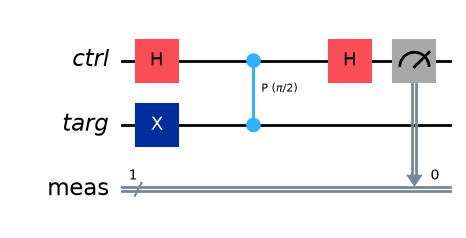

In [3]:
def build_kickback(phi, eigenstate):
    label = "kick" if eigenstate else "no_kick"
    circuit, ctrl, targ = skeleton(f"{label}_phi={phi / math.pi:g}pi")
    if eigenstate:
        circuit.x(targ)           # target in |1>, an eigenstate of P(phi)
    circuit.h(ctrl)               # control in |+>
    circuit.cp(phi, ctrl, targ)   # controlled-P(phi)
    circuit.h(ctrl)               # turn the kicked-back phase into a probability
    circuit.measure(ctrl, circuit.cregs[0])
    return circuit


build_kickback(math.pi / 2, eigenstate=True).draw("mpl")

For comparison, here is the control experiment with the same phase. The target is $|0\rangle$, so the controlled-phase gate does nothing useful and the control should always measure 0.

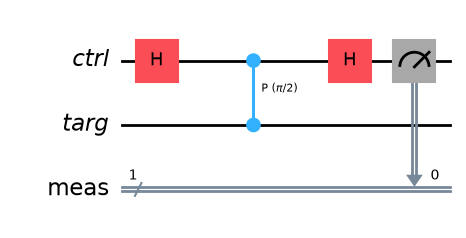

In [4]:
build_kickback(math.pi / 2, eigenstate=False).draw("mpl")

## Step 3: The CX-on-$|-\rangle$ circuit

Here the gate is a CX and the target is $|-\rangle = (|0\rangle - |1\rangle)/\sqrt2$. Because $X|-\rangle = -|-\rangle$, the eigenvalue is $-1 = e^{i\pi}$, so CX acts like a Z on the control and the control should measure 1 every time.

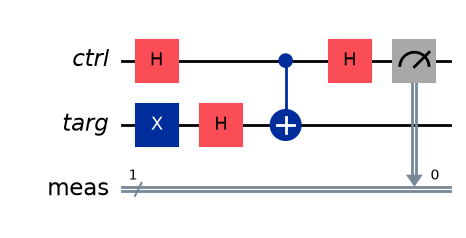

In [5]:
def build_cx_on_minus():
    circuit, ctrl, targ = skeleton("cx_on_minus")
    circuit.x(targ)
    circuit.h(targ)       # target in |->
    circuit.h(ctrl)       # control in |+>
    circuit.cx(ctrl, targ)
    circuit.h(ctrl)
    circuit.measure(ctrl, circuit.cregs[0])
    return circuit


build_cx_on_minus().draw("mpl")

## Step 4: Collect the circuits and the ideal answers

We build every case and store the ideal $P(1)$ for each one, so the report can compare the measured value against theory.

In [6]:
circuits = {}
expected_p1 = {}  # ideal P(1) for each circuit
for p in PHASES:
    phi = p * math.pi
    for eigenstate in (True, False):
        circuit = build_kickback(phi, eigenstate)
        circuits[circuit.name] = circuit
        expected_p1[circuit.name] = math.sin(phi / 2) ** 2 if eigenstate else 0.0
circuits["cx_on_minus"] = build_cx_on_minus()
expected_p1["cx_on_minus"] = 1.0

for name, value in expected_p1.items():
    print(f"{name:<22} ideal P(1) = {value:.3f}")

kick_phi=0pi           ideal P(1) = 0.000
no_kick_phi=0pi        ideal P(1) = 0.000
kick_phi=0.5pi         ideal P(1) = 0.500
no_kick_phi=0.5pi      ideal P(1) = 0.000
kick_phi=1pi           ideal P(1) = 1.000
no_kick_phi=1pi        ideal P(1) = 0.000
cx_on_minus            ideal P(1) = 1.000


## Step 5: The report function

`run_experiments` calls this function once for every finished run. It computes the fraction of shots where the control measured 1 and compares it with the ideal value. Here `where` is `"aer"` or the hardware backend's name.

In [7]:
def report(where, name, counts):
    total = sum(counts.values())
    p1 = counts.get("1", 0) / total
    exp = expected_p1[name]
    status = "ok" if abs(p1 - exp) <= TOLERANCE else "OFF"
    print(f"[{where}] {name:<22} P(1) = {p1:.3f} (expected {exp:.3f}: {status})")

## Step 6: Run

This runs every circuit on the Aer simulator and, if `skip_hardware=False`, on IBM hardware. Every case should be marked `ok`: with $\varphi = 0, \pi/2, \pi$ the kickback cases give $P(1) \approx 0, 0.5, 1$, the control experiments give about 0, and the CX case gives about 1.

In [8]:
args = SimpleNamespace(
    shots=SETTINGS.shots,
    backend=SETTINGS.backend,
    name=SETTINGS.name,
    skip_hardware=SETTINGS.skip_hardware,
    poll_interval=SETTINGS.poll_interval,
)
run_experiments(circuits, args, report)

Example circuit (kick_phi=0pi):
        ┌───┐       ┌───┐┌─┐
  ctrl: ┤ H ├─■─────┤ H ├┤M├
        ├───┤ │P(0) └───┘└╥┘
  targ: ┤ X ├─■───────────╫─
        └───┘             ║ 
meas: 1/══════════════════╩═
                          0 

--- Aer simulator (noiseless), 4096 shots ---
[aer] kick_phi=0pi           P(1) = 0.000 (expected 0.000: ok)
[aer] no_kick_phi=0pi        P(1) = 0.000 (expected 0.000: ok)
[aer] kick_phi=0.5pi         P(1) = 0.500 (expected 0.500: ok)
[aer] no_kick_phi=0.5pi      P(1) = 0.000 (expected 0.000: ok)
[aer] kick_phi=1pi           P(1) = 1.000 (expected 1.000: ok)
[aer] no_kick_phi=1pi        P(1) = 0.000 (expected 0.000: ok)
[aer] cx_on_minus            P(1) = 1.000 (expected 1.000: ok)


0